In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pickle
from pathlib import Path

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")


In [3]:
# Load processed monthly data
DATA_PATH = Path("../data/processed/monthly_scope.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head())


Columns: ['Date', 'Emission_Type', 'Emissions_tCO2e', 'Consumption_Units', 'Year', 'Month']
Shape: (144, 6)
        Date Emission_Type  Emissions_tCO2e  Consumption_Units  Year  Month
0 2020-01-31       Scope 1      1755.795813        4837104.149  2020      1
1 2020-01-31       Scope 2      1908.584310        4837104.149  2020      1
2 2020-02-29       Scope 1      1679.152641        4628859.702  2020      2
3 2020-02-29       Scope 2      1792.904592        4628859.702  2020      2
4 2020-03-31       Scope 1      1871.382396        5079259.195  2020      3


In [4]:
# Scope 1 and Scope 2 filtering
scope1 = df[df["Emission_Type"] == "Scope 1"].set_index("Date")["Emissions_tCO2e"]
scope2 = df[df["Emission_Type"] == "Scope 2"].set_index("Date")["Emissions_tCO2e"]

print("Scope 1 shape:", scope1.shape)
print("Scope 2 shape:", scope2.shape)
print(scope1.tail())


Scope 1 shape: (72,)
Scope 2 shape: (72,)
Date
2025-08-31    1883.014245
2025-09-30    1773.207447
2025-10-31    1742.981019
2025-11-30    1594.453986
2025-12-31    1619.995947
Name: Emissions_tCO2e, dtype: float64


In [5]:
# Train/test split (last 12 months as test)
TEST_MONTHS = 12

def train_test_split_ts(series, test_months=TEST_MONTHS):
    train = series.iloc[:-test_months]
    test = series.iloc[-test_months:]
    return train, test

train1, test1 = train_test_split_ts(scope1)
train2, test2 = train_test_split_ts(scope2)

print(f"Scope 1 — Train: {len(train1)} months | Test: {len(test1)} months")
print(f"Scope 2 — Train: {len(train2)} months | Test: {len(test2)} months")


Scope 1 — Train: 60 months | Test: 12 months
Scope 2 — Train: 60 months | Test: 12 months


In [6]:
# Evaluation function
def evaluate(actual, predicted, model_name, scope):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"[{model_name}] {scope} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    return {"Model": model_name, "Scope": scope, "MAE": round(mae,2), "RMSE": round(rmse,2), "MAPE(%)": round(mape,2)}


In [7]:
# Train and evaluate Holt-Winters
results = []

for scope_name, train, test in [("Scope 1", train1, test1), ("Scope 2", train2, test2)]:
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    ).fit()
    
    pred = model.forecast(steps=TEST_MONTHS)
    pred.index = test.index
    
    results.append(evaluate(test, pred, "Holt-Winters", scope_name))


[Holt-Winters] Scope 1 → MAE: 22.66 | RMSE: 26.93 | MAPE: 1.29%
[Holt-Winters] Scope 2 → MAE: 41.09 | RMSE: 42.62 | MAPE: 3.51%


In [8]:
# Train and evaluate SARIMA
for scope_name, train, test in [("Scope 1", train1, test1), ("Scope 2", train2, test2)]:
    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    
    pred = model.forecast(steps=TEST_MONTHS)
    pred.index = test.index
    
    results.append(evaluate(test, pred, "SARIMA", scope_name))



[SARIMA] Scope 1 → MAE: 36.79 | RMSE: 45.83 | MAPE: 2.11%
[SARIMA] Scope 2 → MAE: 24.98 | RMSE: 34.08 | MAPE: 2.16%


In [9]:
# Comparison table
results_df = pd.DataFrame(results)
print("\n===== MODEL COMPARISON =====")
print(results_df.to_string(index=False))



===== MODEL COMPARISON =====
       Model   Scope   MAE  RMSE  MAPE(%)
Holt-Winters Scope 1 22.66 26.93     1.29
Holt-Winters Scope 2 41.09 42.62     3.51
      SARIMA Scope 1 36.79 45.83     2.11
      SARIMA Scope 2 24.98 34.08     2.16


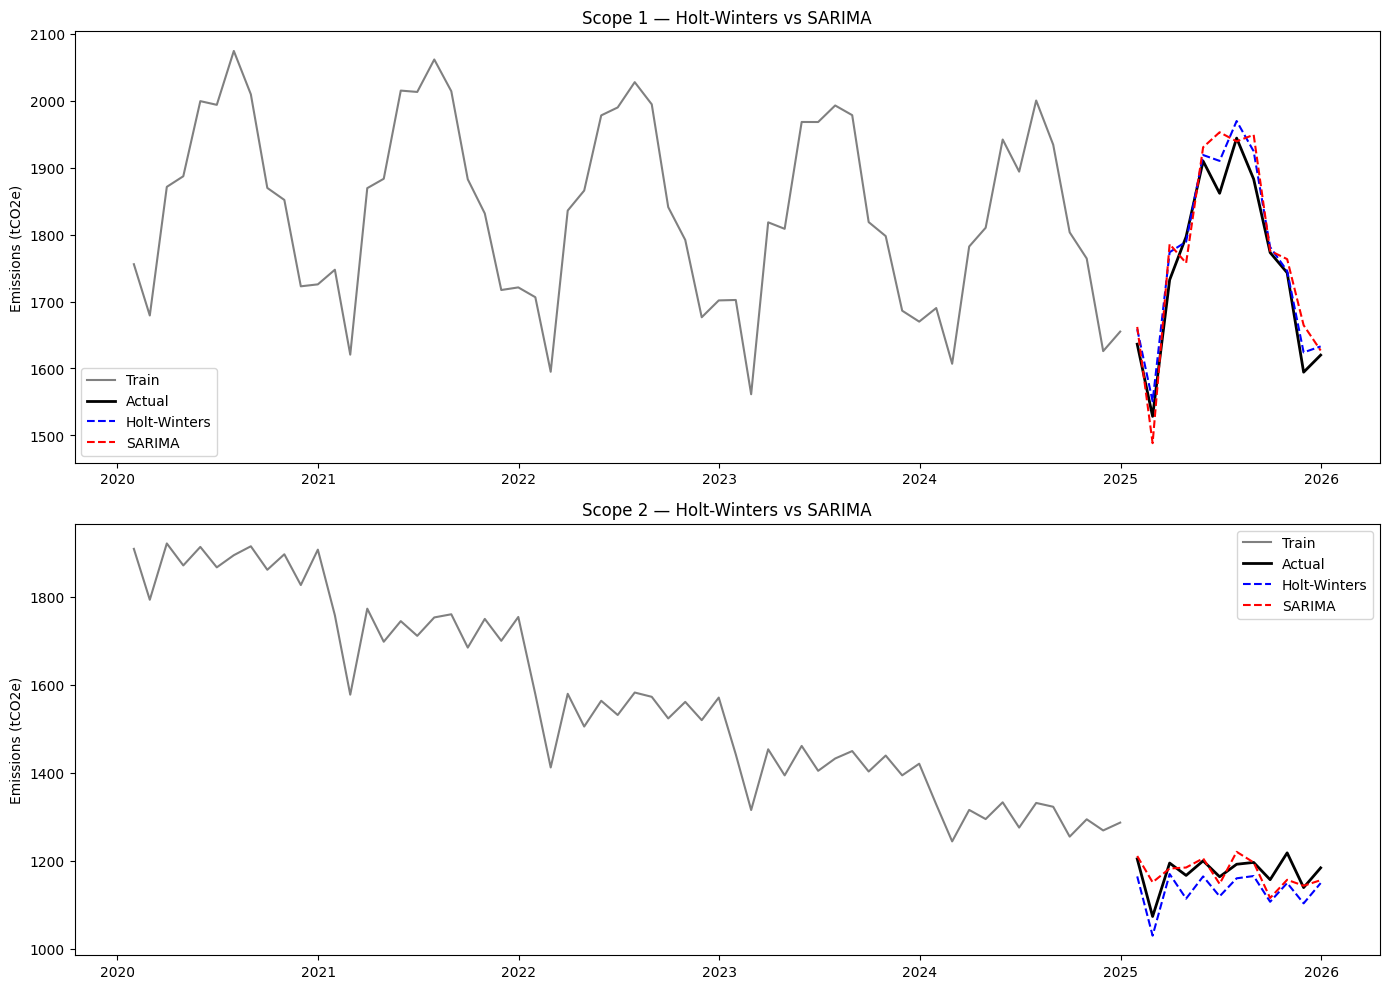

In [12]:
# Visual comparison plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, scope_name, train, test in zip(
    axes,
    ["Scope 1", "Scope 2"],
    [train1, train2],
    [test1, test2]
):
    # Holt-Winters forecast
    hw_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
    hw_pred = hw_model.forecast(TEST_MONTHS)
    hw_pred.index = test.index

    # SARIMA forecast
    sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    sarima_pred = sarima_model.forecast(TEST_MONTHS)
    sarima_pred.index = test.index

    ax.plot(train.index, train, label="Train", color="gray")
    ax.plot(test.index, test, label="Actual", color="black", linewidth=2)
    ax.plot(hw_pred.index, hw_pred, label="Holt-Winters", color="blue", linestyle="--")
    ax.plot(sarima_pred.index, sarima_pred, label="SARIMA", color="red", linestyle="--")
    ax.set_title(f"{scope_name} — Holt-Winters vs SARIMA")
    ax.legend()
    ax.set_ylabel("Emissions (tCO2e)")

plt.tight_layout()
plt.savefig("../data/processed/figures/model_comparison.png", dpi=150)
plt.show()


In [13]:
# Save winning Holt-Winters models for both scopes
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

for scope_name, train in [("Scope 1", train1), ("Scope 2", train2)]:
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    ).fit()
    
    filename = "scope1_model.pkl" if scope_name == "Scope 1" else "scope2_model.pkl"
    with open(MODEL_DIR / filename, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved {filename}")

print("All models saved successfully.")


Saved scope1_model.pkl
Saved scope2_model.pkl
All models saved successfully.
